In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.svm import LinearSVC, SVC
from sklearn.preprocessing import RobustScaler, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score


In [2]:
path = "/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/Data/A1_2_PCA_training_data.csv"

df_training_data = pd.read_csv(path)
df_training_data = df_training_data.iloc[:,1:]

df_unseen_data = pd.read_csv("/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/Data/A2_unseen_data_ukb_adni_o3.csv")
df_unseen_data = df_unseen_data.iloc[:,1:]

full_dataset = pd.concat([df_training_data, df_unseen_data], axis=0)
full_dataset = full_dataset.dropna()
demographic_data = full_dataset.iloc[:,:5]
brain_features =  full_dataset.iloc[:,5:]

full_dataset = full_dataset.drop(columns=["Dataset"])
diagnosis = full_dataset.pop("Diagnosis")
full_dataset.insert(0, "Diagnosis", diagnosis)

/scratch/quirom/slurm_job_53757184/ipykernel_3933999/2565252488.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  full_dataset.insert(0, "Diagnosis", diagnosis)


In [3]:
y = full_dataset["Diagnosis"]
X = full_dataset.iloc[:,4:]

/home/preclineu/quirom/.conda/envs/norm_vae/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/preclineu/quirom/.conda/envs/norm_vae/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/preclineu/quirom/.conda/envs/norm_vae/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      1604
         1.0       0.71      0.95      0.81       165
         2.0       0.00      0.00      0.00        52

    accuracy                           0.96      1821
   macro avg       0.57      0.65      0.60      1821
weighted avg       0.94      0.96      0.95      1821

[[1588   16    0]
 [   8  157    0]
 [   3   49    0]]
Accuracy: 0.958264689730917
parameters for C: 0.01, parameters for gamma: 0.01


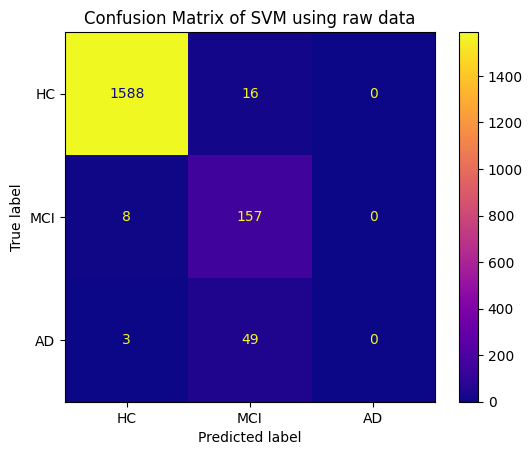

/home/preclineu/quirom/.conda/envs/norm_vae/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/preclineu/quirom/.conda/envs/norm_vae/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/preclineu/quirom/.conda/envs/norm_vae/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      1604
         1.0       0.71      0.95      0.81       165
         2.0       0.00      0.00      0.00        52

    accuracy                           0.96      1821
   macro avg       0.57      0.65      0.60      1821
weighted avg       0.94      0.96      0.95      1821

[[1588   16    0]
 [   8  157    0]
 [   3   49    0]]
Accuracy: 0.958264689730917
parameters for C: 0.01, parameters for gamma: 10


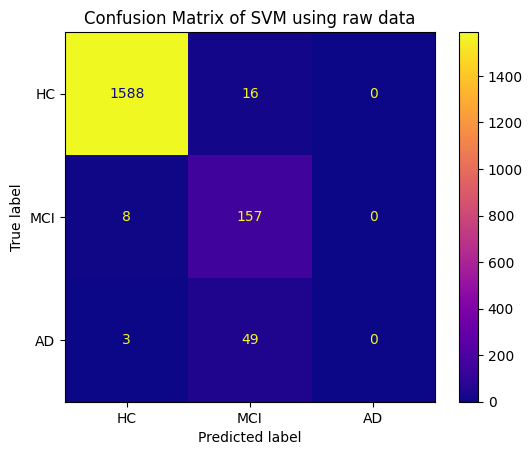

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Cs = [0.01, 100.0]
gammas = [0.01, 10]

for C in Cs:
    for gamma in gammas:
        # use LinearSVC for high-dimensional data or SVC for non-linear kernels 'rbf'
        clf = make_pipeline(StandardScaler(), SVC(kernel='linear', C=C, gamma=gamma))
        
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)   
        print(classification_report(y_test, y_pred))
        print(confusion_matrix(y_test, y_pred))
        print("Accuracy:", clf.score(X_test, y_test))  
        print(f"parameters for C: {C}, parameters for gamma: {gamma}")
        
        cm = confusion_matrix(y_test, y_pred)
        labels = ['HC', 'MCI', 'AD']
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
        disp.plot(cmap='plasma')
        plt.title('Confusion Matrix of SVM using raw data')
        plt.show()

Balanced SVMs
regularization
https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html
cross-validation metrics voor AUC
https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc_crossval.html

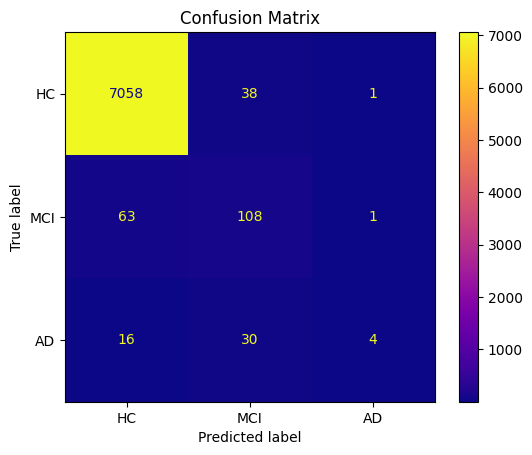

In [65]:
cm = confusion_matrix(y_test, y_pred)
labels = ['HC', 'MCI', 'AD']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='plasma')
plt.title('Confusion Matrix of SVM using raw data')
plt.show()

accuracy: 0.957 ± 0.003
precision_macro: 0.518 ± 0.013
recall_macro: 0.717 ± 0.021
f1_macro: 0.579 ± 0.016


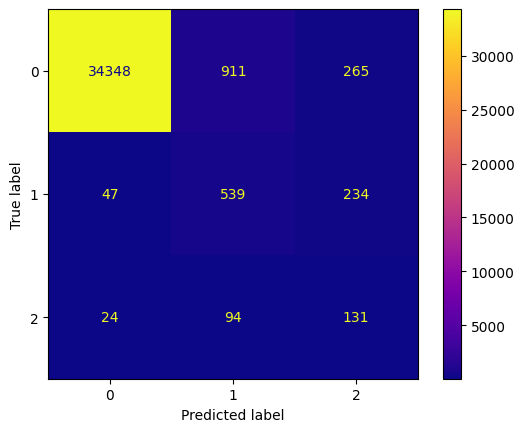

In [19]:
C = 1
gamma = 0.01

clf = make_pipeline(StandardScaler(), SVC(kernel='linear', C=C, gamma=gamma, decision_function_shape='ovr', class_weight='balanced'))

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision_macro': make_scorer(precision_score, average='macro'),
    'recall_macro': make_scorer(recall_score, average='macro'),
    'f1_macro': make_scorer(f1_score, average='macro')}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    clf, X, y, cv=cv, scoring=scoring,
    return_train_score=False, return_estimator=True
)

for metric in scoring.keys():
    print(f"{metric}: {np.mean(cv_results[f'test_{metric}']):.3f} ± {np.std(cv_results[f'test_{metric}']):.3f}")

y_pred = cross_val_predict(clf, X, y, cv=cv)

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='plasma')
plt.show()

accuracy: 0.934 ± 0.005
precision_macro: 0.667 ± 0.017
recall_macro: 0.723 ± 0.018
f1_macro: 0.686 ± 0.016


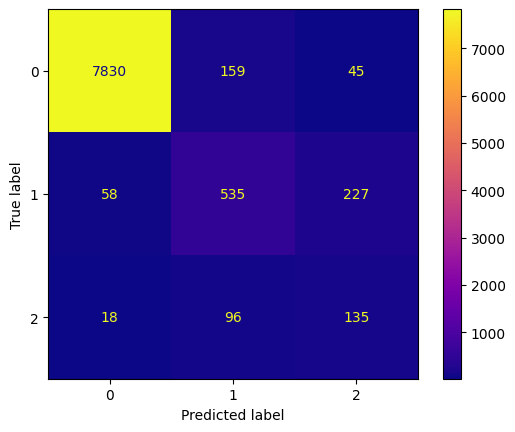

NameError: name 'labels' is not defined

In [9]:
C = 1
gamma = 0.01

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y, random_state=42)

clf = make_pipeline(StandardScaler(), SVC(kernel='linear', C=C, gamma=gamma, decision_function_shape='ovr', class_weight='balanced', probability=True))

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision_macro': make_scorer(precision_score, average='macro'),
    'recall_macro': make_scorer(recall_score, average='macro'),
    'f1_macro': make_scorer(f1_score, average='macro')}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    clf, X, y, cv=cv, scoring=scoring,
    return_train_score=False, return_estimator=True
)

for metric in scoring.keys():
    print(f"{metric}: {np.mean(cv_results[f'test_{metric}']):.3f} ± {np.std(cv_results[f'test_{metric}']):.3f}")

y_pred = cross_val_predict(clf, X, y, cv=cv)

cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='plasma')
plt.show()

y_test_bin = label_binarize(y_test, classes=labels)

y_score = clf.predict_proba(X_test)

n_classes = len(labels)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())

roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

macro_auc = roc_auc_score(y_test_bin, y_score, multi_class='ovr', average='macro')

plt.figure()

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'{labels[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot(fpr["micro"], tpr["micro"], linestyle='--', label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve (SVM)')
plt.legend()
plt.show()

print(f"Macro AUC: {macro_auc:.3f}")
print(f"Micro AUC: {roc_auc['micro']:.3f}")


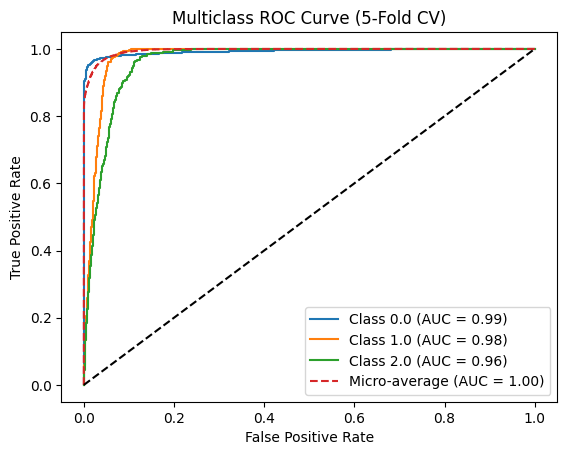

Macro AUC: 0.978
Micro AUC: 0.995


In [10]:
y_score = cross_val_predict(
    clf, X, y, cv=cv, method='predict_proba'
)

classes = np.unique(y)
y_bin = label_binarize(y, classes=classes)

n_classes = y_bin.shape[1]

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

macro_auc = roc_auc_score(y_bin, y_score, multi_class='ovr', average='macro')


plt.figure()

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot(fpr["micro"], tpr["micro"],
         linestyle='--',
         label=f'Micro-average (AUC = {roc_auc["micro"]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve (5-Fold CV)')
plt.legend()
plt.show()

print(f"Macro AUC: {macro_auc:.3f}")
print(f"Micro AUC: {roc_auc['micro']:.3f}")

              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99      7112
         2.0       0.21      0.88      0.34        43

    accuracy                           0.98      7155
   macro avg       0.61      0.93      0.67      7155
weighted avg       0.99      0.98      0.99      7155

[[6972  140]
 [   5   38]]
Accuracy: 0.9797344514325647
parameters for C: 1, parameters for gamma: 0.01


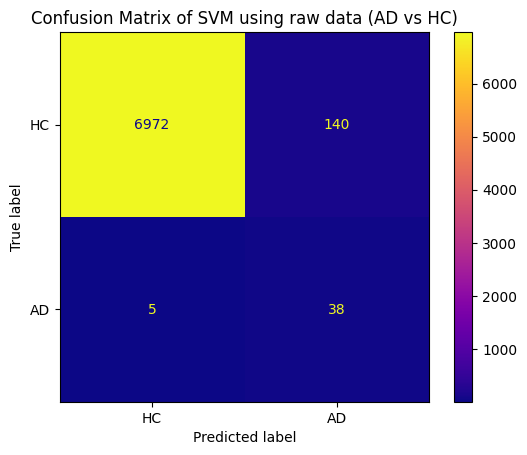

In [16]:
#now lets classify HC vs AD (excluding MCI)
ad_vs_hc = full_data[full_data["Diagnosis"] != 1]

y = ad_vs_hc.iloc[:,0]
X = ad_vs_hc.iloc[:,2:]
X

C = 1
gamma = 0.01

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y, random_state=42)


clf = make_pipeline(StandardScaler(), SVC(kernel='linear', C=C, gamma=gamma, decision_function_shape='ovo', class_weight='balanced'))

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)   
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", clf.score(X_test, y_test))  
print(f"parameters for C: {C}, parameters for gamma: {gamma}")

cm = confusion_matrix(y_test, y_pred)
labels = ['HC', 'AD']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='plasma')
plt.title('Confusion Matrix of SVM using raw data (HC vs AD)')
plt.show()

              precision    recall  f1-score   support

         0.0       1.00      0.97      0.98      7101
         1.0       0.41      0.95      0.57       168

    accuracy                           0.97      7269
   macro avg       0.70      0.96      0.78      7269
weighted avg       0.99      0.97      0.97      7269

[[6869  232]
 [   8  160]]
Accuracy: 0.9669830788278992
parameters for C: 1, parameters for gamma: 0.01


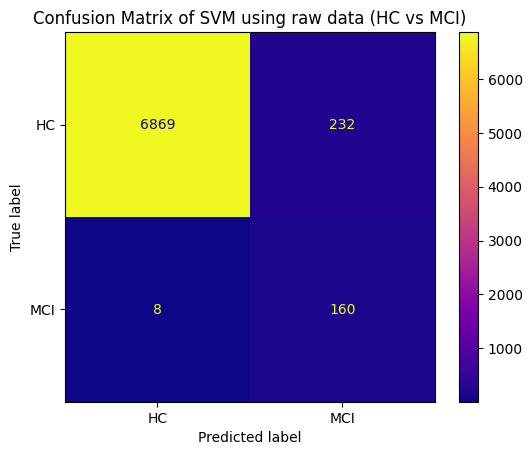

In [18]:
#now lets classify HC vs MCI (excluding AD)
ad_vs_hc = full_data[full_data["Diagnosis"] != 2]

y = ad_vs_hc.iloc[:,0]
X = ad_vs_hc.iloc[:,2:]
X

C = 1
gamma = 0.01

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


clf = make_pipeline(StandardScaler(), SVC(kernel='linear', C=C, gamma=gamma, decision_function_shape='ovo', class_weight='balanced'))

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)   
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", clf.score(X_test, y_test))  
print(f"parameters for C: {C}, parameters for gamma: {gamma}")

cm = confusion_matrix(y_test, y_pred)
labels = ['HC', 'MCI']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='plasma')
plt.title('Confusion Matrix of SVM using raw data (HC vs MCI)')
plt.show()

              precision    recall  f1-score   support

         1.0       0.88      0.63      0.73       165
         2.0       0.36      0.71      0.48        49

    accuracy                           0.65       214
   macro avg       0.62      0.67      0.61       214
weighted avg       0.76      0.65      0.68       214

[[104  61]
 [ 14  35]]
Accuracy: 0.6495327102803738
parameters for C: 1, parameters for gamma: 0.01


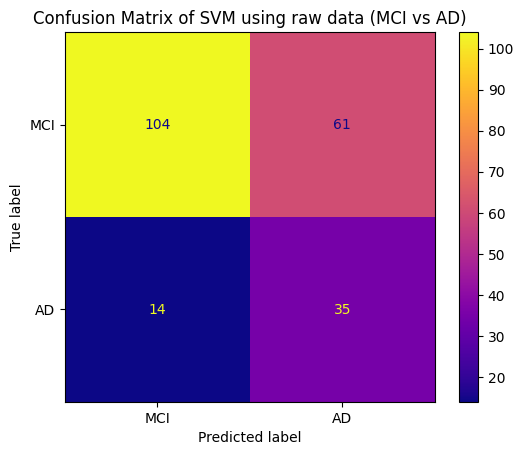

In [20]:
#now lets classify MCI vs AD (excluding HC)
mci_vs_ad = full_data[full_data["Diagnosis"] != 0]

y = mci_vs_ad.iloc[:,0]
X = mci_vs_ad.iloc[:,2:]
X

C = 1
gamma = 0.01

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


clf = make_pipeline(StandardScaler(), SVC(kernel='linear', C=C, gamma=gamma, decision_function_shape='ovo', class_weight='balanced'))

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)   
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("Accuracy:", clf.score(X_test, y_test))  
print(f"parameters for C: {C}, parameters for gamma: {gamma}")

cm = confusion_matrix(y_test, y_pred)
labels = ['MCI', 'AD']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='plasma')
plt.title('Confusion Matrix of SVM using raw data (MCI vs AD)')
plt.show()